In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load admissions dataset
from google.colab import files

uploaded = files.upload()

Saving admissions_clean.csv to admissions_clean.csv


In [2]:
df = pd.read_csv("admissions_clean.csv")

df.head()

,Admission_ID,Patient_ID,Doctor_ID,Department_ID,Admission_Date,Discharge_Date,Status,Length_of_Stay_Days
0,A00001,P00001,DR00186,D002,2025-10-20,2025-10-28,Critical,8
1,A00002,P00002,DR00281,D019,2025-01-21,2025-01-23,Recovered,2
2,A00003,P00003,DR00105,D020,2025-06-24,2025-07-03,Discharged,9
3,A00004,P00004,DR00312,D004,2025-07-23,2025-07-25,Critical,2
4,A00005,P00005,DR00430,D018,2025-04-06,2025-04-07,Under Treatment,1


In [3]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Rows: 5000
Columns: 8

Column Names:
['Admission_ID', 'Patient_ID', 'Doctor_ID', 'Department_ID', 'Admission_Date', 'Discharge_Date', 'Status', 'Length_of_Stay_Days']

Missing Values:
Admission_ID           0
Patient_ID             0
Doctor_ID              0
Department_ID          0
Admission_Date         0
Discharge_Date         0
Status                 0
Length_of_Stay_Days    0
dtype: int64

Duplicate Rows: 0


In [4]:

df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])
df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"])


print(df[["Admission_Date", "Discharge_Date", "Length_of_Stay_Days"]].dtypes)


calculated_los = (df["Discharge_Date"] - df["Admission_Date"]).dt.days

print("\nLOS mismatches:", (calculated_los != df["Length_of_Stay_Days"]).sum())

Admission_Date         datetime64[ns]
Discharge_Date         datetime64[ns]
Length_of_Stay_Days             int64
dtype: object

LOS mismatches: 0


Patient Discharge Status:
Status
Critical           1279
Under Treatment    1272
Recovered          1235
Discharged         1214
Name: count, dtype: int64


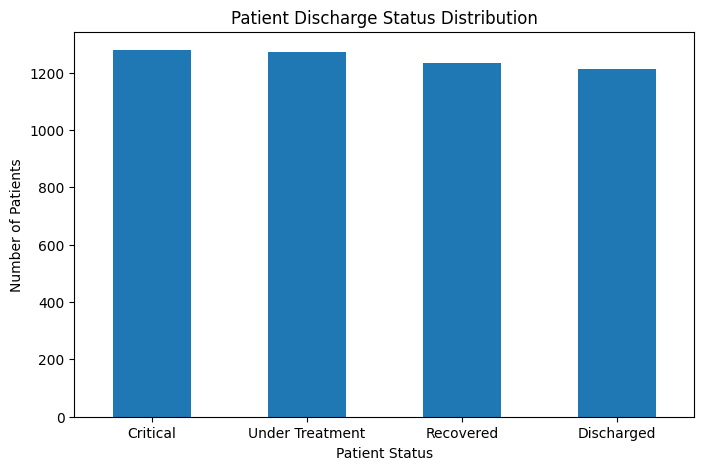

In [5]:
# Discharge status distribution

status_counts = df["Status"].value_counts()

print("Patient Discharge Status:")
print(status_counts)

plt.figure(figsize=(8, 5))
status_counts.plot(kind="bar")
plt.title("Patient Discharge Status Distribution")
plt.xlabel("Patient Status")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

In [6]:
# Average Length of Stay

average_los = df["Length_of_Stay_Days"].mean()

print("Average Length of Stay:", round(average_los, 2), "days")

Average Length of Stay: 5.52 days


In [7]:
# Discharge Rate

total_patients = len(df)
discharged_patients = (df["Status"] == "Discharged").sum()

discharge_rate = (discharged_patients / total_patients) * 100

print("Total Patients:", total_patients)
print("Discharged Patients:", discharged_patients)
print("Discharge Rate:", round(discharge_rate, 2), "%")

Total Patients: 5000
Discharged Patients: 1214
Discharge Rate: 24.28 %


In [8]:
# Monthly patient flow

df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])
df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"])

monthly_admissions = df.groupby(
    df["Admission_Date"].dt.to_period("M")
).size()

monthly_discharges = df.groupby(
    df["Discharge_Date"].dt.to_period("M")
).size()

monthly_flow = pd.DataFrame({
    "Admissions": monthly_admissions,
    "Discharges": monthly_discharges
}).fillna(0)

print(monthly_flow)

         Admissions  Discharges
2025-01       516.0         440
2025-02       479.0         459
2025-03       504.0         504
2025-04       508.0         524
2025-05       519.0         495
2025-06       505.0         522
2025-07       524.0         517
2025-08       506.0         515
2025-09       500.0         498
2025-10       439.0         479
2025-11         0.0          47


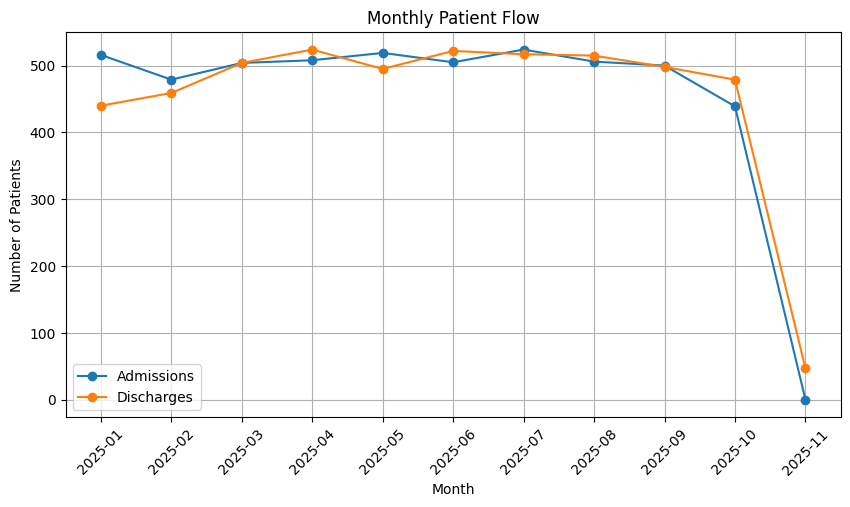

In [9]:
plt.figure(figsize=(10,5))

plt.plot(monthly_flow.index.astype(str),
         monthly_flow["Admissions"],
         marker="o",
         label="Admissions")

plt.plot(monthly_flow.index.astype(str),
         monthly_flow["Discharges"],
         marker="o",
         label="Discharges")

plt.xlabel("Month")
plt.ylabel("Number of Patients")
plt.title("Monthly Patient Flow")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [10]:
# Average Length of Stay by Patient Status

avg_los_status = df.groupby("Status")["Length_of_Stay_Days"].mean()

print(avg_los_status.round(2))

Status
Critical           5.57
Discharged         5.52
Recovered          5.55
Under Treatment    5.42
Name: Length_of_Stay_Days, dtype: float64


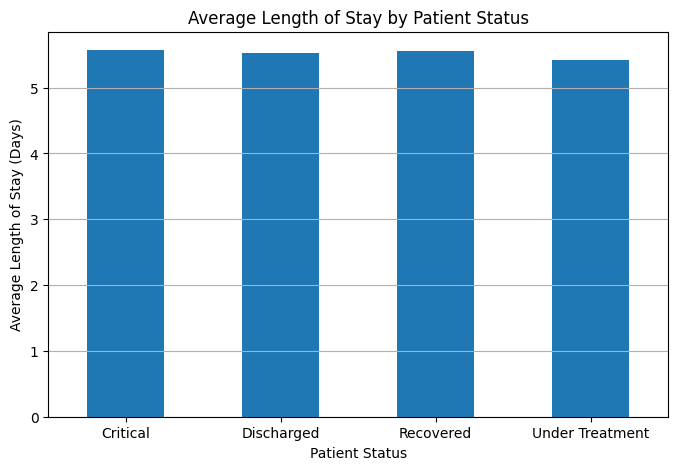

In [11]:
# Average Length of Stay by Patient Status

plt.figure(figsize=(8, 5))

avg_los_status.plot(kind="bar")

plt.xlabel("Patient Status")
plt.ylabel("Average Length of Stay (Days)")
plt.title("Average Length of Stay by Patient Status")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [12]:
# Department-wise Patient Admissions

department_admissions = df["Department_ID"].value_counts().sort_index()

print(department_admissions)

Department_ID
D001    233
D002    200
D003    320
D004    277
D005    331
D006    215
D007    179
D008    175
D009    169
D010    218
D011    159
D012    253
D013    317
D014    260
D015    335
D016    266
D017    253
D018    268
D019    319
D020    253
Name: count, dtype: int64


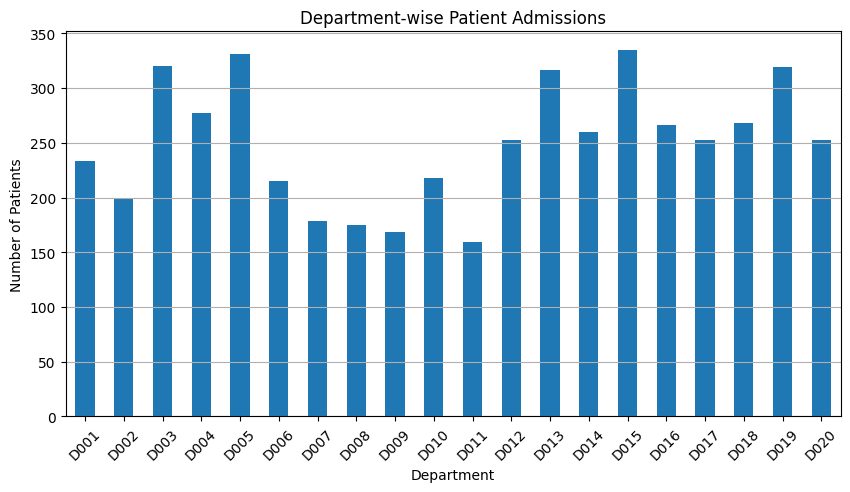

In [13]:
# Department-wise Patient Admissions

plt.figure(figsize=(10, 5))

department_admissions.plot(kind="bar")

plt.xlabel("Department")
plt.ylabel("Number of Patients")
plt.title("Department-wise Patient Admissions")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [14]:
# Department-wise Patient Discharges

department_discharges = (
    df[df["Status"] == "Discharged"]
    .groupby("Department_ID")
    .size()
    .sort_index()
)

print(department_discharges)

Department_ID
D001    39
D002    55
D003    64
D004    84
D005    89
D006    59
D007    43
D008    38
D009    35
D010    49
D011    34
D012    66
D013    74
D014    65
D015    75
D016    71
D017    61
D018    62
D019    89
D020    62
dtype: int64


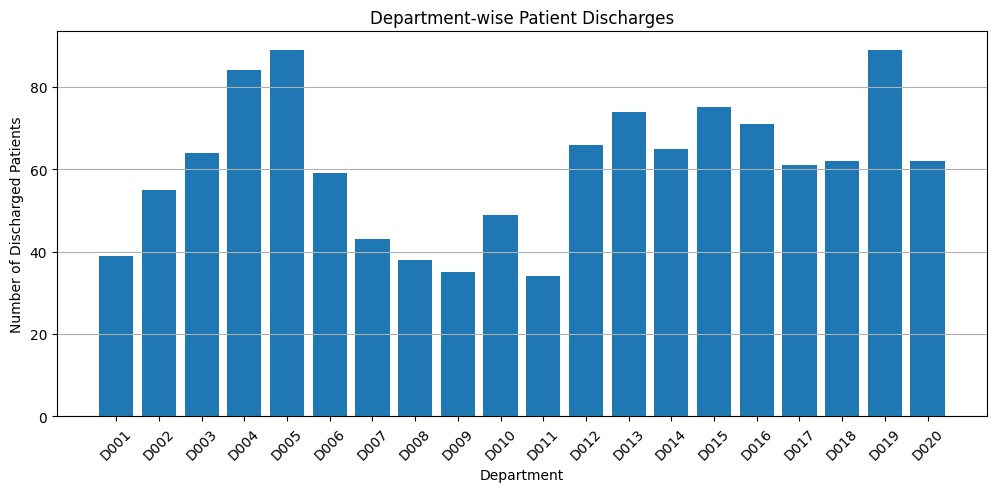

In [15]:
# Department-wise Patient Discharges

plt.figure(figsize=(12, 5))

plt.bar(
    department_discharges.index,
    department_discharges.values
)

plt.title("Department-wise Patient Discharges")
plt.xlabel("Department")
plt.ylabel("Number of Discharged Patients")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [16]:
# Department-wise Discharge Rate

department_discharge_rate = (
    department_discharges / department_admissions * 100
).fillna(0)

print(department_discharge_rate.round(2))

Department_ID
D001    16.74
D002    27.50
D003    20.00
D004    30.32
D005    26.89
D006    27.44
D007    24.02
D008    21.71
D009    20.71
D010    22.48
D011    21.38
D012    26.09
D013    23.34
D014    25.00
D015    22.39
D016    26.69
D017    24.11
D018    23.13
D019    27.90
D020    24.51
dtype: float64


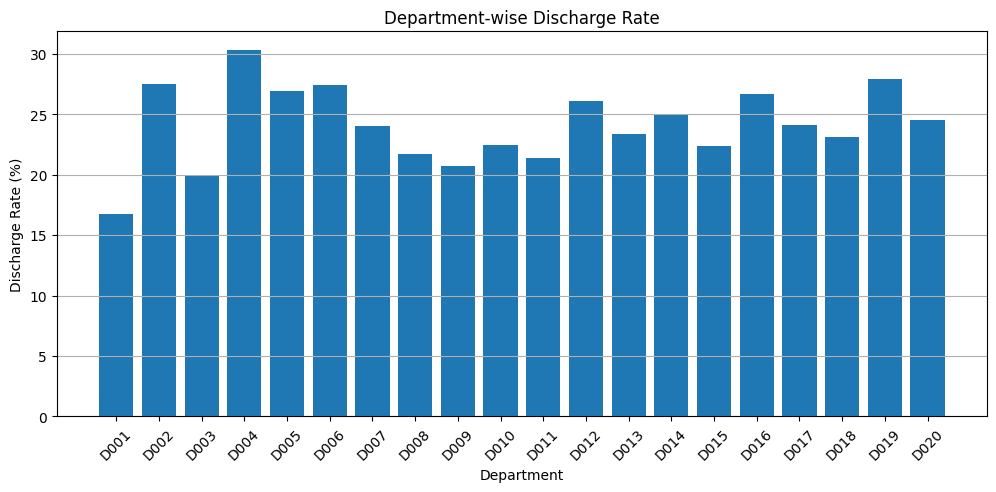

In [17]:
# Department-wise Discharge Rate Chart

plt.figure(figsize=(12, 5))

plt.bar(
    department_discharge_rate.index,
    department_discharge_rate.values
)

plt.title("Department-wise Discharge Rate")
plt.xlabel("Department")
plt.ylabel("Discharge Rate (%)")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [18]:
# Average Length of Stay by Department

department_avg_los = (
    df.groupby("Department_ID")["Length_of_Stay_Days"]
    .mean()
    .sort_index()
)

print(department_avg_los.round(2))

Department_ID
D001    5.39
D002    5.44
D003    5.50
D004    5.54
D005    5.40
D006    5.52
D007    5.59
D008    5.35
D009    5.57
D010    5.89
D011    5.43
D012    5.65
D013    5.21
D014    5.33
D015    5.61
D016    5.57
D017    5.66
D018    5.45
D019    5.67
D020    5.56
Name: Length_of_Stay_Days, dtype: float64


In [19]:
# Monthly Discharge Rate

monthly_total = df.groupby(
    df["Discharge_Date"].dt.to_period("M")
).size()

monthly_discharged = df[df["Status"] == "Discharged"].groupby(
    df[df["Status"] == "Discharged"]["Discharge_Date"].dt.to_period("M")
).size()

monthly_discharge_rate = (
    monthly_discharged / monthly_total * 100
).fillna(0)

print(monthly_discharge_rate.round(2))

Discharge_Date
2025-01    25.45
2025-02    22.44
2025-03    24.80
2025-04    21.95
2025-05    27.47
2025-06    25.29
2025-07    21.86
2025-08    25.05
2025-09    23.49
2025-10    25.68
2025-11    19.15
Freq: M, dtype: float64


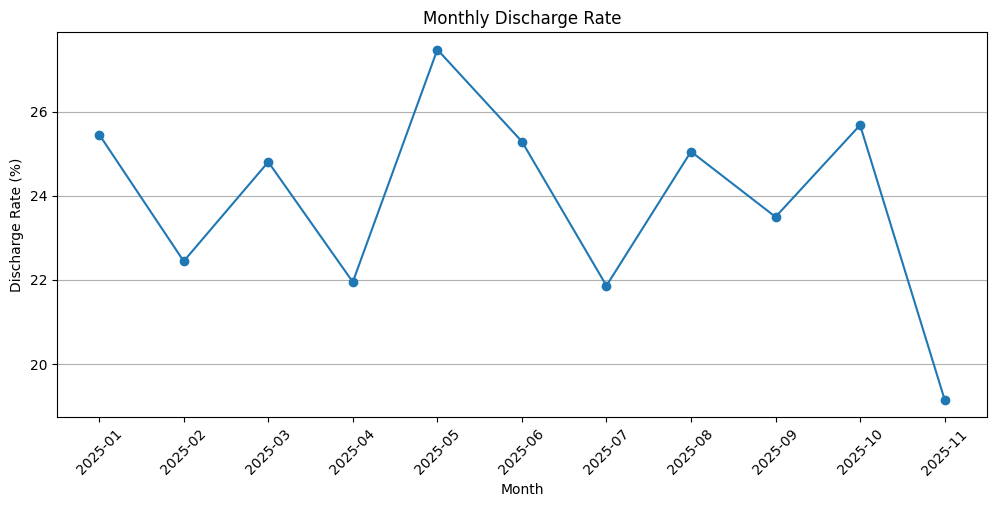

In [21]:
# Monthly Discharge Rate Chart

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_discharge_rate.index.astype(str),
    monthly_discharge_rate.values,
    marker="o"
)

plt.title("Monthly Discharge Rate")
plt.xlabel("Month")
plt.ylabel("Discharge Rate (%)")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [22]:
# Patient Flow Summary by Status

status_summary = df["Status"].value_counts()

print(status_summary)

Status
Critical           1279
Under Treatment    1272
Recovered          1235
Discharged         1214
Name: count, dtype: int64


In [23]:
# Monthly Patient Flow Gap

monthly_flow["Flow_Gap"] = (
    monthly_flow["Admissions"] - monthly_flow["Discharges"]
)

print(monthly_flow)

         Admissions  Discharges  Flow_Gap
2025-01       516.0         440      76.0
2025-02       479.0         459      20.0
2025-03       504.0         504       0.0
2025-04       508.0         524     -16.0
2025-05       519.0         495      24.0
2025-06       505.0         522     -17.0
2025-07       524.0         517       7.0
2025-08       506.0         515      -9.0
2025-09       500.0         498       2.0
2025-10       439.0         479     -40.0
2025-11         0.0          47     -47.0


 Key Findings & KPI Summary

 Overall KPIs
- Total patients: 5,000
- Average Length of Stay: 5.52 days
- Discharge Rate: 24.28%

 Patient Status
- Critical: 1,279
- Under Treatment: 1,272
- Recovered: 1,235
- Discharged: 1,214

 Patient Flow
- Monthly admissions and discharges remained relatively close in most months.
- March recorded the highest number of discharges (584).
- July recorded the highest number of admissions (524).
- November shows incomplete admission coverage in the dataset.

 Length of Stay
- Critical patients had the highest average LOS: 5.57 days.
- Under Treatment patients had the lowest average LOS: 5.42 days.
- LOS was relatively similar across patient statuses.

 Department-wise Flow
- D015 had the highest admissions: 335.
- D011 had the lowest admissions: 159.
- D004 had the highest department discharge rate: 30.32%.
- D001 had the lowest department discharge rate: 16.74%.